    # Week 10 - Unsupervised machine learning and magma storage pressures

One of the major topics in volcanology is determining the pressures, and therefore depths, at which magmas are stored beneath volcanoes. This information helps to interpret pre-eruptive warning signals (e.g., are seismic signals tracking magma movement or fluid circulation in an overlying hydrothermal system). Pinpointing magma storage depths is also critical for our understanding of mineral deposits - e.g., what are the conditions that allow them to form?

In this assignment we're going to look at some mineral data from the island of Floreana in the Galápagos Archipelago. While this isn't an active or particularly hazardous volcano it represents an interesting 'endmember' type of volcanic system as it erupts in highly energetic and explosive events every 20 - 30 thousand years (as shown by the types of volcanic deposits found on the island). Investigating these 'low activity' volcanoes helps us construct more genetic models of how magma systems form, and the underlying processes that control their characteristics.

![Galapagos Map](https://www.galapagos.org/wp-content/uploads/2022/05/Galapagos-Islands-Map-with-Islands-Names-copy-scaled.jpg)

![Floreana island](https://www.islandconservation.org/wp-content/uploads/2024/09/island-conservation-invasive-species-preventing-extinctions-floreana-island-coastline-feat-1.jpg)

Specifically we're going to look at the chemical data of a mineral known as clinopyroxene. Clinopyroxenes are typically characterised by the chemical formula $CaMgSi_2O_6$, but at high pressure incorporate small amounts of Na and Al into the structure ($NaAlSi_2O_6$). This allows us to use the composition of clinopyroxene to estimate the depth of magma storage - i.e., the clinopyroxene Na content records the pressure at which the crystal grew!

![clinopyroxene image](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQBnS7t_pc6YgMlvPhar_Nt7aw0h2grDu23Ew&s)

The problem, is that if the clinopyroxene didn't grow from the magma it erupted in, it cannot be used for these calculations! Secondary processes operating after initial crystal growth (i.e., chemical reactions taking place in the solid crust) can change the crystal chemistry, so we need to identify the crystals that grew directly from the magma. This is especially important at Floreana where clinopyroxene bearing 'xenoliths' (fragments of solid rocks unrelated to the erupted melt). We want to find a way to ensure that the loose clinopyroxene crystals separated from scoria flows on the island didn't originate within a xenolith and instead grew directly from the erupted melt.

One way to do this is through cluster analysis, a common form of unsupervised machine learning.

![Clustering Schematic](https://scikit-learn.org/stable/_images/sphx_glr_plot_cluster_comparison_001.png)

As with any and all assignments let's load in the required packages. In addition to our standard packages (Pandas, NumPy, matplotlib) we'll also load several types of clustering from sklearn as well as the ```StandardScaler``` class from the preprocessing submodule.

We will also load the ```dendrogram``` and ```linkage``` methods from scipy to help visualize the clusters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

## Exercise 1 - Examining apparent crystallization pressures

First, as in all notebooks, let's load in the data. Here we're loading in 550 analyses of clinopyroxenes from Floreana that I made during my PhD. As before, let's use the ```.head()``` method to inspect the DataFrame. This should reveal the presence of a column called `Type`.

In [2]:
# Load rock sample data
data = pd.read_excel('data/Floreana_clinopyroxene.xlsx')
data.head()

,Sample,Comment,Mineral,Session no.,Type,P_kbar,SiO2_Cpx,TiO2_Cpx,Al2O3_Cpx,Cr2O3_Cpx,FeOt_Cpx,MgO_Cpx,CaO_Cpx,Na2O_Cpx
0,17MMSG16,16p4-1,cpx,1,Scoria,8.362149,49.8219,0.6661,7.0864,0.0442,7.2392,14.0366,20.0991,0.6960
1,17MMSG16,16p4-1,cpx,1,Scoria,8.440187,49.5610,0.6537,7.1702,0.0376,7.2306,13.8833,19.7857,0.6702
2,17MMSG16,16p4-1,cpx,1,Scoria,9.101004,50.3633,0.6602,7.1480,0.0602,7.0927,13.7663,19.8640,0.7156
3,17MMSG16,16p4-2,cpx,1,Scoria,9.174600,49.8030,0.6479,7.3362,0.0258,7.2627,13.8473,19.7837,0.7424
4,17MMSG16,16p4-2,cpx,1,Scoria,8.767960,50.2693,0.6639,7.3752,0.0317,7.1847,13.8933,19.7704,0.6709


This `Type` indicates where I found (and measured) each clinopyroxene. Samples with `data['Type'] == 'Scoria'` were found as loose crystals within the lava and *might* represent crystals that grew directly from the erupted melt. Let's use the `.unique()` method to look at what other types are listed in this dataset.

In [13]:
data.columns

Index(['Sample', 'Comment', 'Mineral', 'Session no.', 'Type', 'P_kbar',
       'SiO2_Cpx', 'TiO2_Cpx', 'Al2O3_Cpx', 'Cr2O3_Cpx', 'FeOt_Cpx', 'MgO_Cpx',
       'CaO_Cpx', 'Na2O_Cpx'],
      dtype='str')

In [3]:
data['Type'].unique()

<StringArray>
['Scoria', 'Wehrlite', 'Dunite', 'Gabbro']
Length: 4, dtype: str

You should see 'Wehrlite', 'Dunite', and 'Gabbro' listed. These are all types of clinopyroxene bearing xenoliths.

What we can do first is calculate the 'apparent' crystallization pressure for all clinopyroxenes in the dataset. Create 4 histograms below using the kwarg `orientation="horizontal"` to display the estimated pressures for each `Type`. The pressures are calculated using the equation of Wang et al. (2021) using the Python library Thermobar, calculating pressures isn't the critical aspect of this assignment, but I can provide more information if anyone wants.

**(5 points)**

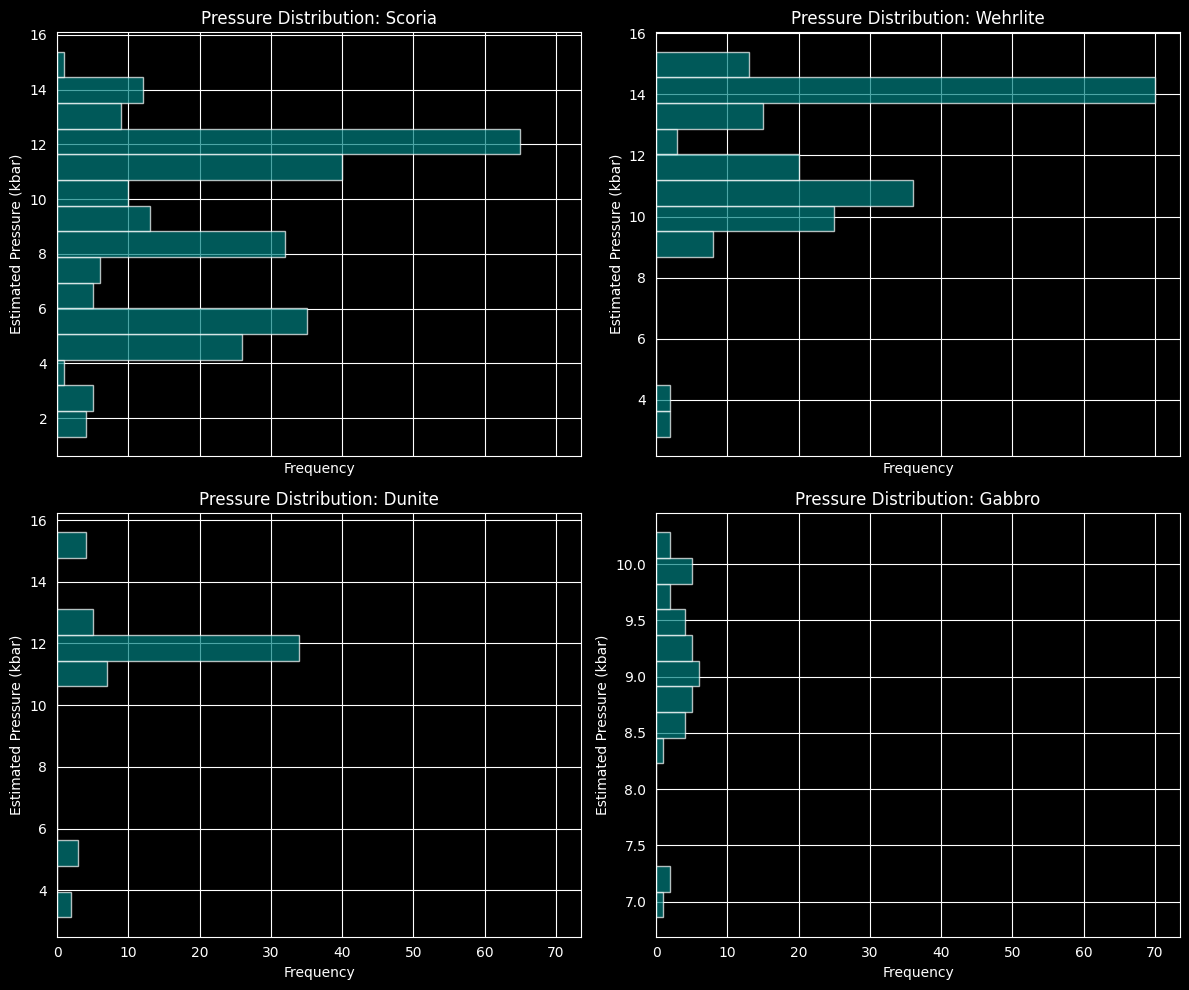

In [4]:
### Create a 4 panel plot of histograms showing the estimated pressures for each `Type`
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()
types = data['Type'].unique()

for i, rock_type in enumerate(types):
    subset = data[data['Type'] == rock_type]

    axes[i].hist(subset['P_kbar'], orientation="horizontal",
                 bins=15, color='teal', edgecolor='white', alpha=0.7)
    axes[i].set_title(f"Pressure Distribution: {rock_type}")
    axes[i].set_ylabel("Estimated Pressure (kbar)")
    axes[i].set_xlabel("Frequency")

plt.tight_layout()
plt.show()


**(5 points)** What do you notice about the distribution of pressure in the scoria clinopyroxenes compared to the other three groups?

It has two peaks of pressures at around 5 kbar and 12 kbar while other types only have peak around 12 kbar

**(5 points)** Beneath Isla Floreana the Moho (the boundary between the oceanic crust and mantle) is about 16 km deep, corresponding to a pressure of ~4.5 kbar. How does this compare to the results and why might this boundary represent a like magma stalling zone based on the image below (hint, look at the densities of the different regions)?

![Crustal Structure](https://www.coolgeography.co.uk/GCSE/AQA/Restless%20Earth/Tectonics/Crustal_types.jpg)

Because of the difference in density, magma from the mantle stops to go upward and creates magma stalling zone, which results in pressure frequency peak around 4.5 kbar.

## Exercise 2 - Data Exploration

**(10 points)** Create 2 scatter plots of the clinopyroxene data using any combination of the oxides contained within the original DataFrame. Plot the different types in different colors, are obvious differences appearing in the data?

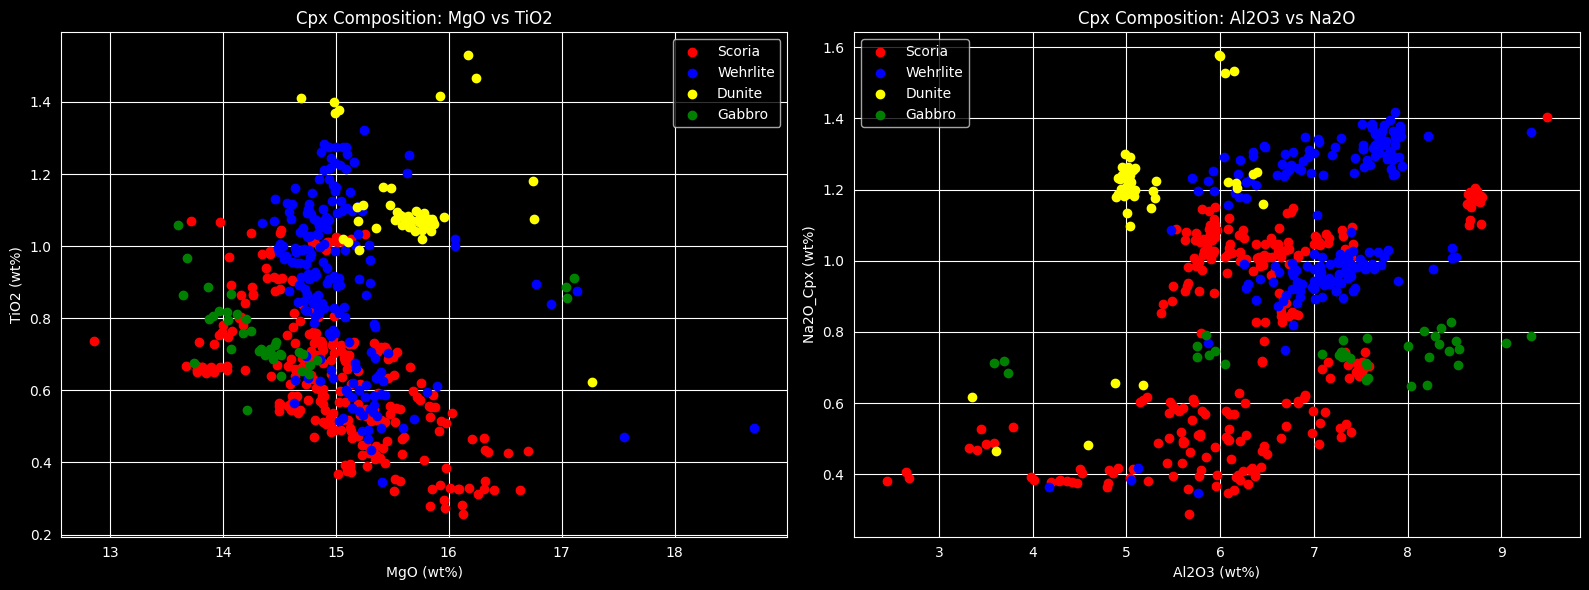

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = {'Scoria': 'red', 'Wehrlite': 'blue', 'Dunite': 'yellow', 'Gabbro': 'green'}

for rock_type, color in colors.items():
    subset = data[data['Type'] == rock_type]
    ax1.scatter(subset['MgO_Cpx'], subset['TiO2_Cpx'],
                label=rock_type, color=color)

ax1.set_xlabel('MgO (wt%)')
ax1.set_ylabel('TiO2 (wt%)')
ax1.set_title('Cpx Composition: MgO vs TiO2')
ax1.legend()

for rock_type, color in colors.items():
    subset = data[data['Type'] == rock_type]
    ax2.scatter(subset['Al2O3_Cpx'], subset['Na2O_Cpx'],
                label=rock_type, color=color)

ax2.set_xlabel('Al2O3 (wt%)')
ax2.set_ylabel('Na2O_Cpx (wt%)')
ax2.set_title('Cpx Composition: Al2O3 vs Na2O')
ax2.legend()

plt.tight_layout()
plt.show()

We'll now create a filtered DataFrame including only the chemical data (i.e., removing all the sample information). We're doing this so that we can apply a standard scaling to our data before performing PCA or cluster analysis. The `StandardScaler` class of `sklearn` will transform and normalize the data in each column of our DataFrame according to the equation:

$$ X_{new} = \frac{x - \mu}{sd} $$

where $x$ is the original data, $\mu$ is the mean of the data, and $sd$ is the standard deviation in the dataset.

In [6]:
### Create a filtered DataFrame by taking all the columns after (and including) SiO2_Cpx
filt_data = data.loc[:, 'SiO2_Cpx':].copy()

# Apply the standard scaling to the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(filt_data)

Now we have scaler data, we can perform principal component analysis (PCA). PCA reduced the 'dimensionality' of the data and can help to visualize difference between groups. We can also analyze the PCA data to examine which variables (or combination of variables) are controlling the distribution of compositions within a dataset.

**(10 points)** Complete the code cell below to perform PCA on the scaled dataset. Plot PCA component 1 against PCA components 2 and 3 using the matplotlib subplot functions and color the data by the `Type`. Are we starting to see clear differences between the groups?

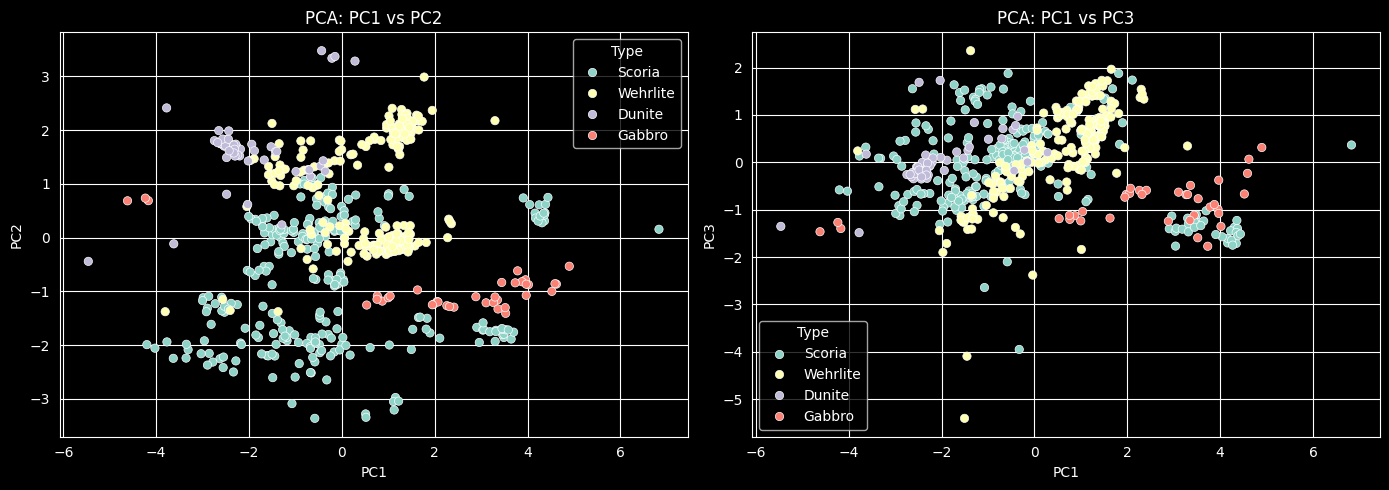

In [7]:
# Apply PCA
pca = PCA(n_components=3)
data_pca = pca.fit_transform(data_scaled)

# Plot the results
pca_df = pd.DataFrame(data_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Type'] = data['Type'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Type', ax=ax1)
ax1.set_title('PCA: PC1 vs PC2')

sns.scatterplot(data=pca_df, x='PC1', y='PC3', hue='Type', ax=ax2)
ax2.set_title('PCA: PC1 vs PC3')

plt.tight_layout()
plt.show()

In the cell below we can make a new DataFrame, this time with the oxides as the index and PC1, PC2, and PC3 as the column headers. Each value in the DataFrame represents the PCA loadings, i.e., the contribution of that element to the variance in that principal component. Higher absolute values indicate a higher contribution to that principal component.

**(5 points)** What pair of elements represent the strongest contribution to the variance of each PC?

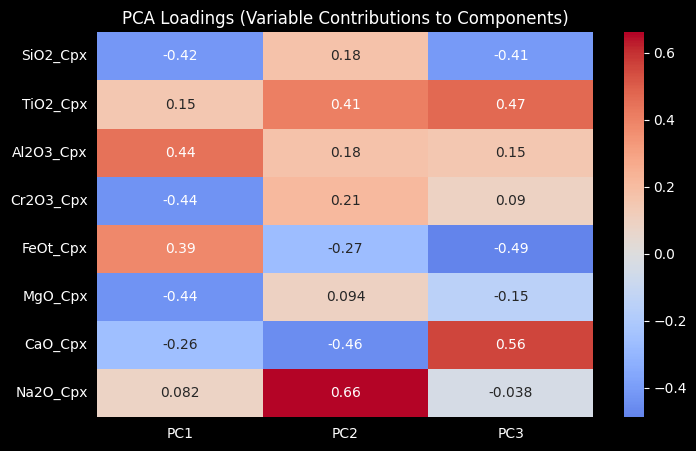

In [8]:
# Get loadings (a.k.a. component weights)
loadings = pca.components_.T  # shape: (n_features, n_components)

# Optionally create a DataFrame for readability
loading_df = pd.DataFrame(loadings, 
                          columns=[f'PC{i+1}' for i in range(pca.n_components_)],
                          index=filt_data.columns) 

plt.figure(figsize=(8, 5))
sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
plt.title('PCA Loadings (Variable Contributions to Components)')
plt.show()

PC1 and Al2O3, PC2 and Na2O, PC3 and CaO

## Exercise 3 - Clustering

**K-means clustering** is an unsupervised machine learning algorithm used to group similar data points into K distinct clusters based on their features.

Key Steps:
1. Choose K: Decide the number of clusters (K).
2. Initialize centroids: Randomly select K points as initial cluster centers.
3. Assign clusters: Each data point is assigned to the nearest centroid based on distance (usually Euclidean).
4. Update centroids: Calculate the new centroids as the mean of all points in each cluster.
5. Repeat: Steps 3 and 4 are repeated until the centroids stop changing significantly or a maximum number of iterations is reached.

Goal:
Minimize the within-cluster sum of squares (WCSS)—the variance within each cluster.

Pros:
- Simple and fast.
- Works well with large datasets.

Cons:
- Must predefine K.
- Sensitive to outliers and initial centroids.
- Assumes clusters are spherical and equally sized.

**(10 points)** In the cell below use `KMeans` class from `sklearn` to create n clusters from the clinopyroxene data (used the scaled data NOT the PCA scores). Try using different numbers of clusters to see how this affects the data, but for much of the following code I will assume we've used 4 clusters (as we have 4 groups in our loaded data).

In [10]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(
 |      n_clusters=8,
 |      *,
 |      init='k-means++',
 |      n_init='auto',
 |      max_iter=300,
 |      tol=0.0001,
 |      verbose=0,
 |      random_state=None,
 |      copy_x=True,
 |      algorithm='lloyd'
 |  )
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empiric

In [11]:
# Apply K-Means
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(data_scaled)

kmeans_labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1,
       1, 3, 3, 3, 3, 0, 0, 2, 2, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1,
       3, 3, 3, 1, 0, 0, 3, 3, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1,
       1, 1, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 3, 2, 2, 1, 1, 1, 0, 0, 0, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0,

**(5 points)** Plot any combination of oxides and color by the cluster labels. Try plotting different oxide combinations. What parameters (oxides) or combination of parameters appear to be defining each cluster?

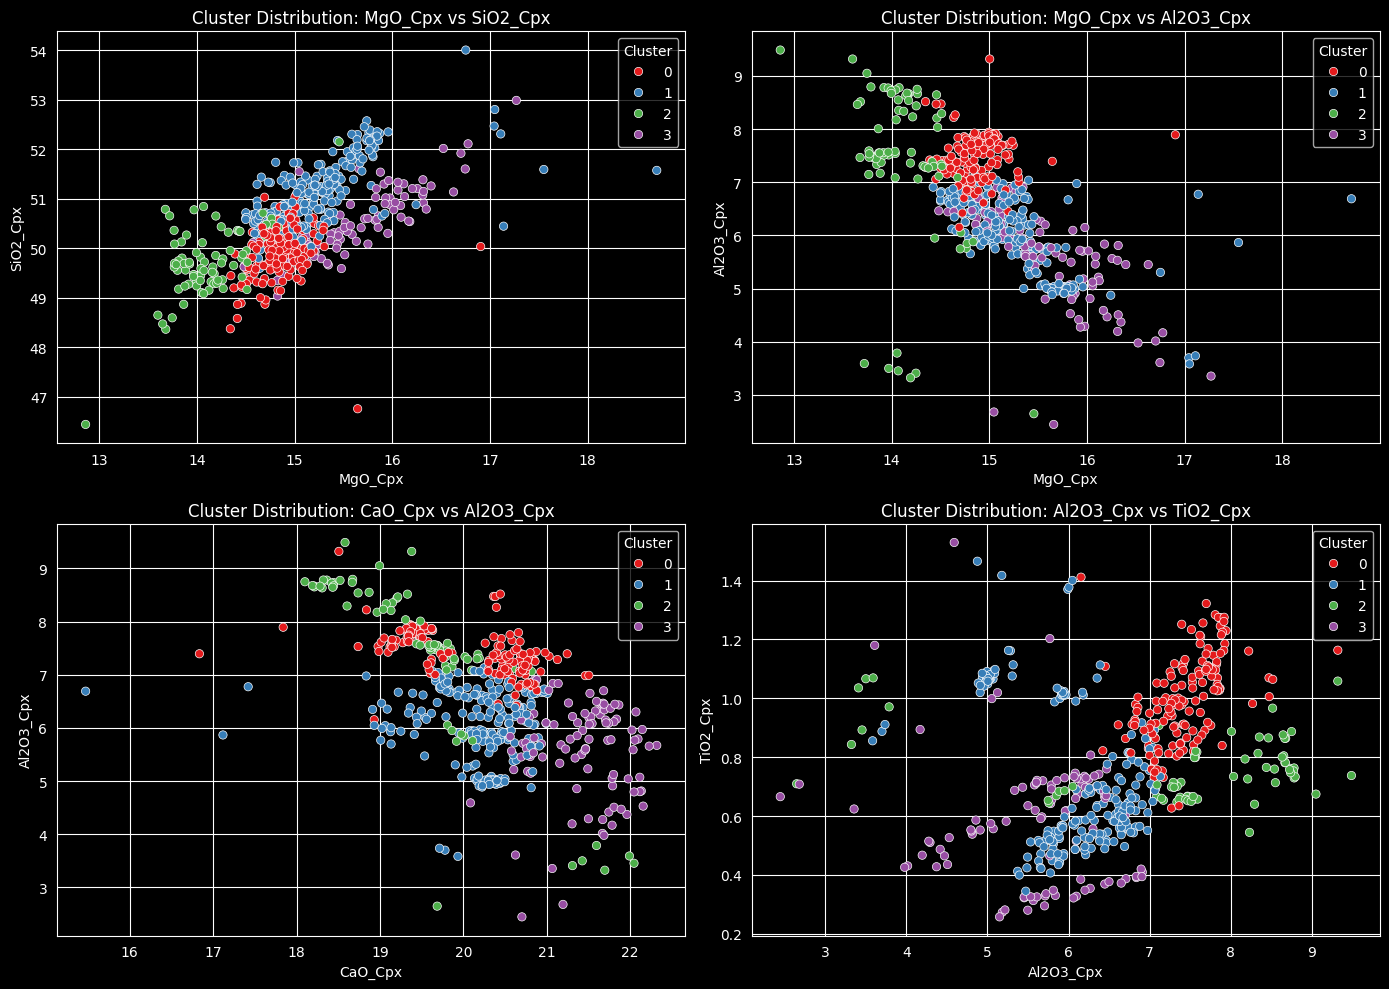

In [18]:
# Plot the results
plot_df = data.copy()
plot_df['Cluster'] = kmeans_labels

combinations = [
    ('MgO_Cpx', 'SiO2_Cpx'),
    ('MgO_Cpx', 'Al2O3_Cpx'),
    ('CaO_Cpx', 'Al2O3_Cpx'),
    ('Al2O3_Cpx', 'TiO2_Cpx')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(combinations):
    sns.scatterplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        hue='Cluster',
        palette='Set1',
        ax=axes[i]
    )
    axes[i].set_title(f'Cluster Distribution: {x_col} vs {y_col}')
    axes[i].legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

**Hierarchical Clustering** is an unsupervised learning method that builds a hierarchy of clusters based on the distance (Euclidean Distance) between clusters.

Types:
1. Agglomerative (Bottom-Up) – Most common
- Start with each data point as its own cluster.
- Iteratively merge the closest pair of clusters.
- Stop when all points are in one cluster or a stopping criterion is met.

2. Divisive (Top-Down) – Less common
- Start with all points in one cluster.
- Recursively split clusters into smaller ones.

Steps (Agglomerative):
- Compute the distance matrix between all data points.
- Merge the two closest clusters.
- Update the distance matrix.
- Repeat until one cluster remains or a desired number of clusters is reached.

Linkage Methods (How distance between clusters is measured):
- Single linkage: Min distance between elements of each cluster.
- Complete linkage: Max distance.
- Average linkage: Average pairwise distance.
- Ward’s method: Minimize variance increase.

Output:
- Often visualized as a dendrogram (tree-like diagram).
- You can "cut" the dendrogram at a certain height to form clusters.

**(10 points)** Do the same for hierachical clustering using the `AgglomerativeClustering` class from `sklearn`. Plot up the results. In your view is KMeans of hierachical clustering doing 'better' (this is a very subjective question)? The standard linkage method applied here it 'Ward's Method' (see lecture).

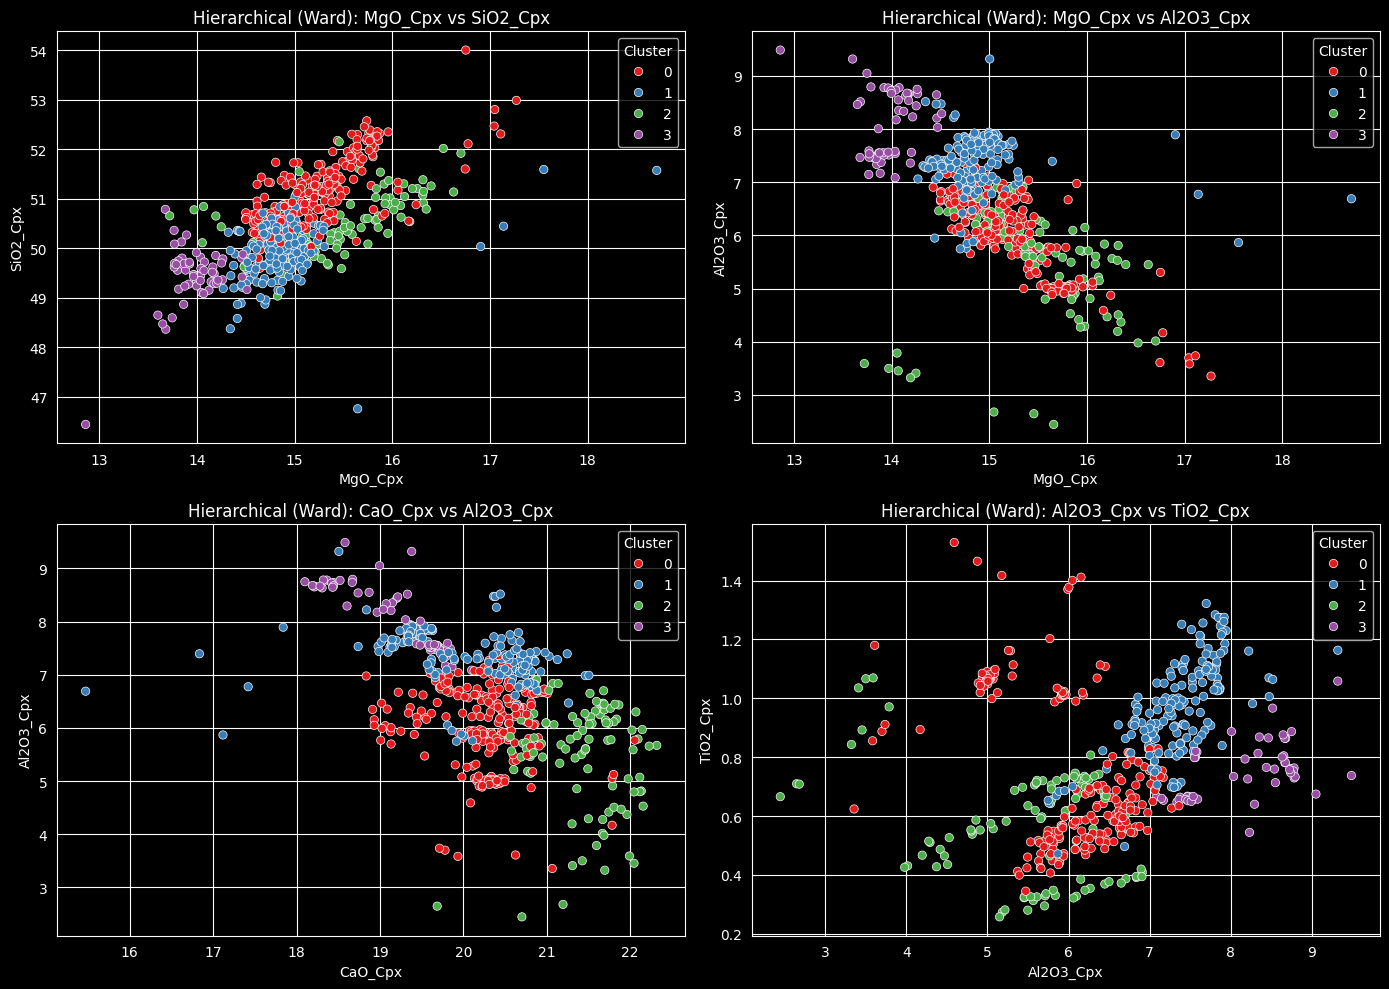

In [21]:
# Apply Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(data_scaled)

# Plot the results
plot_df['hierarchical_cluster'] = hierarchical_labels

combinations = [
    ('MgO_Cpx', 'SiO2_Cpx'),
    ('MgO_Cpx', 'Al2O3_Cpx'),
    ('CaO_Cpx', 'Al2O3_Cpx'),
    ('Al2O3_Cpx', 'TiO2_Cpx')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(combinations):
    sns.scatterplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        hue='hierarchical_cluster',
        palette='Set1',
        ax=axes[i]
    )
    axes[i].set_title(f'Hierarchical (Ward): {x_col} vs {y_col}')
    axes[i].legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

In my view, k-means cluster categorises well .

As indicated above one of the best ways to visualize hierarchical clustering is with a Dendrogram. This represents a visualization of the distance between clusters on the y-axis and demonstrates how the grouping might change if you increase the number of clusters.

**(10 points)** Complete the code below to create and plot a dendrogram using the `linkage` method from `scipy` make sure to specify `method = 'ward'` so that this is equivalent to what we did above. Then use the `dendogram` function to plot these results.

We selected 4 clusters. Does this seem appropriate given the dendrogram below?

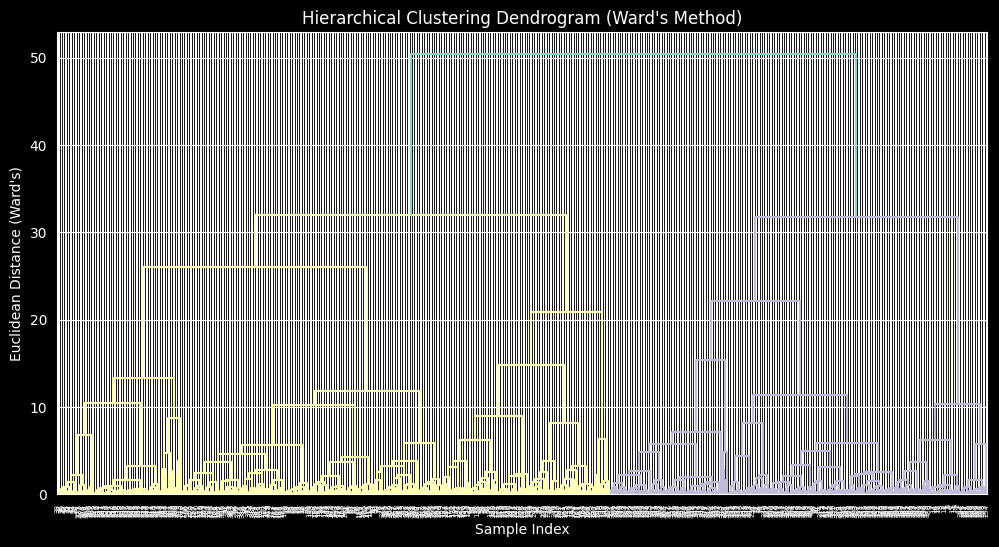

In [26]:
# Compute the linkage matrix
linked = linkage(data_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram (Ward\'s Method)')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance (Ward\'s)')
plt.show()

From the graph, it seems to be also understandable when we choose n=5 as well as n=4.

The final clustering approach we will consider (although you don't have to write any new code) is **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** an unsupervised clustering algorithm that groups together points that are closely packed (dense regions) and labels points in low-density regions as noise/outliers.

Key Concepts:
- ε (epsilon): Radius that defines the neighborhood around a point.
- MinPts: Minimum number of points required to form a dense region (cluster).
- Core Point: Has at least MinPts within ε.
- Border Point: Has fewer than MinPts within ε but is in the neighborhood of a core point.
- Noise Point: Neither a core nor a border point.

Steps:
- For each point, check how many neighbors it has within ε.
- If it's a core point, start a new cluster and expand it by connecting it to neighboring core/border points.
- Continue until all points are visited.

Pros:
- No need to specify number of clusters in advance.
- Can find arbitrarily shaped clusters.
- Identifies outliers/noise.
- Works well with clusters of varying shapes and sizes.

Cons:
- Choice of ε and MinPts is crucial and sometimes tricky.
- Struggles with varying densities.
- Not ideal for high-dimensional data.

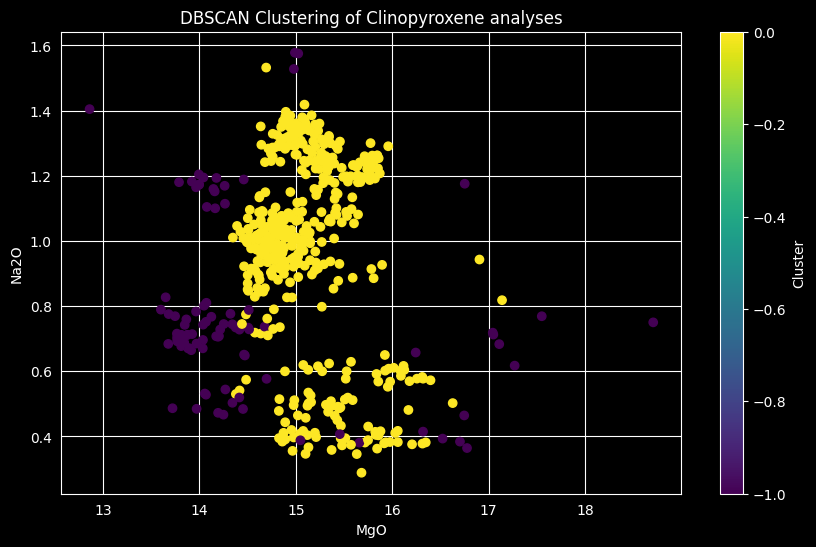

In [27]:
# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=50)
dbscan_labels = dbscan.fit_predict(data_pca)

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(filt_data['MgO_Cpx'], filt_data['Na2O_Cpx'],  c=dbscan_labels, cmap='viridis')
plt.xlabel('MgO')
plt.ylabel('Na2O')
plt.title('DBSCAN Clustering of Clinopyroxene analyses')
plt.colorbar(label='Cluster')
plt.show()

#### BONUS
**Try applying these different clustering methods to the PCA components rather than the scaled data. How does this change the results?**

## Exercise 4 - Comparing clusters to initial classifications

**(20 points)** In the space below create histograms for each `Type` in the original dataset showing the proportion of samples from each `Type` that belong to each of the three (or n) cluster identified by the K-means, Hierarchical, and DBSCAN clustering performed above. I've provided the code to do this for K-means clustering results, try and do the same for the other two methods. 

When looking at these results also try to calculate determine which method is most effective at isolating crystals that originate from the wehrlite or gabbro xenoliths.

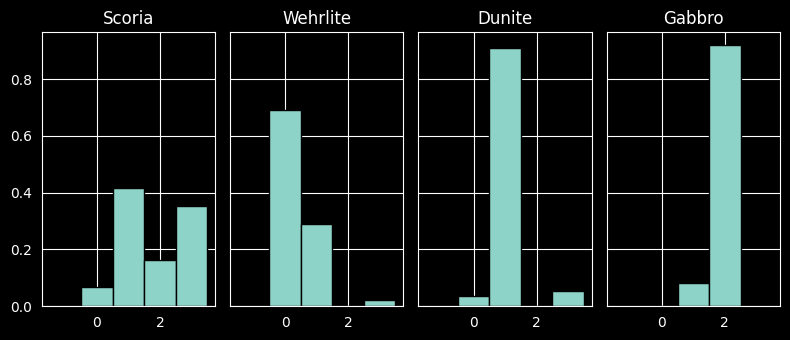

In [28]:
# Histograms for K-means clustering
types = data['Type'].unique()

f, a = plt.subplots(1,len(types), figsize = (8, 3.5), sharey = True)
for idx, t in enumerate(types):
    a[idx].hist(kmeans_labels[data['Type'] == t], bins = np.arange(-1.5, 4.5, 1), 
                edgecolor = 'k', density = True)
    a[idx].set_title(t)


f.tight_layout()

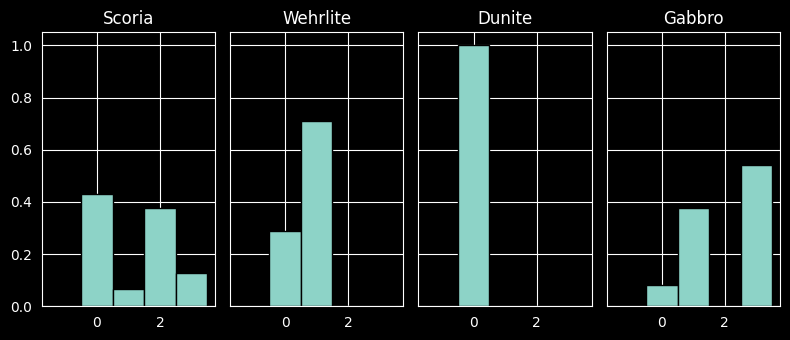

In [30]:
# Do the same for Hierarchical clustering
f, a = plt.subplots(1, len(types), figsize=(8, 3.5), sharey=True)

for idx, t in enumerate(types):
    a[idx].hist(hierarchical_labels[data['Type'] == t], bins=np.arange(-1.5, 4.5, 1),
                edgecolor='k', density=True)
    a[idx].set_title(t)

f.tight_layout()

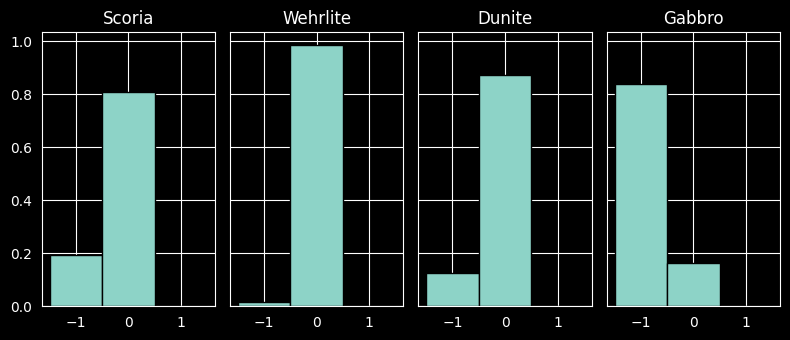

In [33]:
# And for DBSCAN
f, a = plt.subplots(1, len(types), figsize=(8, 3.5), sharey=True)

for idx, t in enumerate(types):
    a[idx].hist(dbscan_labels[data['Type'] == t], bins=np.arange(-1.5, len(np.unique(dbscan_labels)) + 0.5, 1),
                edgecolor='k', density=True)
    a[idx].set_title(t)

f.tight_layout()

We can now examine the final results

**(10 points)** Plot histograms for the pressure (P_kbar) for the cluster that best represents data that does NOT originate from one of the xenolith groups. Plot 2 histograms, one for the results of K-means clustering and one for the results of hierarchical clustering. Plot only the samples that are initially defined as "Scoria" and fall into the chosen cluster

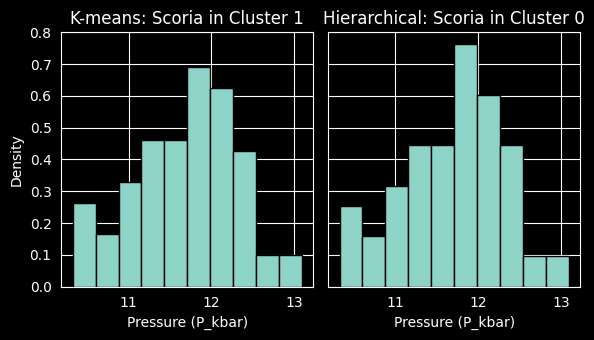

In [38]:
f, a = plt.subplots(1,2, figsize = (6,3.5), sharey=True)
best_cluster_km = 1
best_cluster_hc = 0

km_scoria_p = data[(data['Type'] == 'Scoria') & (kmeans_labels == best_cluster_km)]['P_kbar']
hc_scoria_p = data[(data['Type'] == 'Scoria') & (hierarchical_labels == best_cluster_hc)]['P_kbar']

a[0].hist(km_scoria_p, bins=10, edgecolor='k', density=True)
a[0].set_title('K-means: Scoria in Cluster 1')
a[0].set_xlabel('Pressure (P_kbar)')
a[0].set_ylabel('Density')

a[1].hist(hc_scoria_p, bins=10, edgecolor='k', density=True)
a[1].set_title('Hierarchical: Scoria in Cluster 0')
a[1].set_xlabel('Pressure (P_kbar)')

f.tight_layout()
plt.show()

**(10 points)** Write a brief discussion about the clustering results and what this means for the pressure of magma storage beneath Floreana (remember the crust-mantle boundary, the Moho) is found at a pressure of ~450 MPa.

The peak of Scoria is around at 12 P_kbar. This is far above the 450 MPa = 4.5 kbar. Hence, Scoria seems to be generateg beneath the Moho.